In [1086]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import warnings
import seaborn as sns
warnings.filterwarnings('ignore')

In [1087]:
data = pd.read_csv('LoanData.csv')
data.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicationIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP100001,Male,Yes,0,Graduate,No,3601,1596.0,140.0,360.0,0.0,Rural,Rejected
1,LP100002,Female,Yes,0,Not Graduate,No,1343,869.0,75.0,360.0,1.0,Semi Urban,Approved
2,LP100003,Female,No,2,Graduate,No,3986,5565.0,171.0,360.0,1.0,NaN,Approved
3,LP100004,Male,No,0,Graduate,No,8264,3272.0,195.0,360.0,1.0,Rural,Approved
4,LP100005,Male,No,0,Graduate,Yes,6720,861.0,110.0,360.0,1.0,Urban,Approved


## Data Understanding

- Loan_ID : Unique Loan ID
- Gender : Male/Female
- Married : Appkicant married
- Dependents : Number of dependents
- Education : Applicant Education
- Self_Employed : whether the applicant is Self employed
- ApplicationIncome: Applicant income
- CoapplicantIncome : Coapplicant income
- LoanAmount : Loan amount in thousands
- Loan_Amount_Term : Term of loan in months
- Credit_History : credit history meets guidelines
- Property_Area : Urban / Semi Urban / Rural
- Loan_Status : Loan approved **target variable**

In [1088]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            1000 non-null   str    
 1   Gender             988 non-null    str    
 2   Married            990 non-null    str    
 3   Dependents         985 non-null    str    
 4   Education          1000 non-null   str    
 5   Self_Employed      988 non-null    str    
 6   ApplicationIncome  1000 non-null   int64  
 7   CoapplicantIncome  990 non-null    float64
 8   LoanAmount         988 non-null    float64
 9   Loan_Amount_Term   990 non-null    float64
 10  Credit_History     985 non-null    float64
 11  Property_Area      990 non-null    str    
 12  Loan_Status        1000 non-null   str    
dtypes: float64(4), int64(1), str(8)
memory usage: 143.6 KB


In [1089]:
data.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicationIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='str')

In [1090]:
data.isnull().sum()

Loan_ID               0
Gender               12
Married              10
Dependents           15
Education             0
Self_Employed        12
ApplicationIncome     0
CoapplicantIncome    10
LoanAmount           12
Loan_Amount_Term     10
Credit_History       15
Property_Area        10
Loan_Status           0
dtype: int64

In [1091]:
data['Loan_ID'].nunique()

1000

#### **Drop unimportant columns as per feature Selection (Filter methods)**

In [1092]:
data.drop(columns=['Loan_ID'], inplace=True)

In [1093]:
data['Gender'].unique()

<ArrowStringArray>
['Male', 'Female', nan]
Length: 3, dtype: str

In [1094]:
data.Married.unique()

<ArrowStringArray>
['Yes', 'No', nan]
Length: 3, dtype: str

In [1095]:
data.Married.value_counts()

Married
Yes    622
No     368
Name: count, dtype: int64

In [1096]:
data.Dependents.unique()

<ArrowStringArray>
['0', '2', '1', '3+', nan]
Length: 5, dtype: str

In [1097]:
data.Dependents.value_counts()

Dependents
0     570
2     180
1     160
3+     75
Name: count, dtype: int64

In [1098]:
data.Credit_History.value_counts()

Credit_History
1.0    799
0.0    186
Name: count, dtype: int64

In [1099]:
data.Dependents.unique()

<ArrowStringArray>
['0', '2', '1', '3+', nan]
Length: 5, dtype: str

In [1100]:
data.Dependents.value_counts()

Dependents
0     570
2     180
1     160
3+     75
Name: count, dtype: int64

In [1101]:
data.Education.unique()

<ArrowStringArray>
['Graduate', 'Not Graduate']
Length: 2, dtype: str

In [1102]:
data.Education.value_counts()

Education
Graduate        735
Not Graduate    265
Name: count, dtype: int64

In [1103]:
data.Self_Employed.unique()

<ArrowStringArray>
['No', 'Yes', nan]
Length: 3, dtype: str

In [1104]:
data.isnull().sum()

Gender               12
Married              10
Dependents           15
Education             0
Self_Employed        12
ApplicationIncome     0
CoapplicantIncome    10
LoanAmount           12
Loan_Amount_Term     10
Credit_History       15
Property_Area        10
Loan_Status           0
dtype: int64

#### **Create a Columns as per requirements**

In [1105]:
data['Income'] = data.ApplicationIncome + data.CoapplicantIncome
data.drop(columns=['ApplicationIncome', 'CoapplicantIncome'], inplace=True)

In [1106]:
data.Income.describe()

count      990.000000
mean      7555.141414
std       3572.283349
min       1477.000000
25%       5016.500000
50%       6837.500000
75%       9441.500000
max      30166.000000
Name: Income, dtype: float64

In [1107]:
data.Loan_Amount_Term.unique()

array([360., 240., 480.,  nan, 180., 120., 300.])

In [1108]:
data.Loan_Amount_Term.value_counts()

Loan_Amount_Term
360.0    731
300.0     70
480.0     66
240.0     61
180.0     32
120.0     30
Name: count, dtype: int64

In [1109]:
data.Credit_History.unique()

array([ 0.,  1., nan])

In [1110]:
data.Credit_History.value_counts()

Credit_History
1.0    799
0.0    186
Name: count, dtype: int64

In [1111]:
data['Credit_History'] = data.Credit_History.replace({1:'good', 0:'bad'})

In [1112]:
data.Credit_History.unique()

array(['bad', 'good', nan], dtype=object)

In [1113]:
data.Credit_History.value_counts()

Credit_History
good    799
bad     186
Name: count, dtype: int64

In [1114]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income
0,Male,Yes,0,Graduate,No,140.0,360.0,bad,Rural,Rejected,5197.0
1,Female,Yes,0,Not Graduate,No,75.0,360.0,good,Semi Urban,Approved,2212.0
2,Female,No,2,Graduate,No,171.0,360.0,good,NaN,Approved,9551.0
3,Male,No,0,Graduate,No,195.0,360.0,good,Rural,Approved,11536.0
4,Male,No,0,Graduate,Yes,110.0,360.0,good,Urban,Approved,7581.0


In [1115]:
data.Credit_History.unique()

array(['bad', 'good', nan], dtype=object)

In [1116]:
data.Credit_History.value_counts()

Credit_History
good    799
bad     186
Name: count, dtype: int64

In [1117]:
data.Property_Area.unique()

<ArrowStringArray>
['Rural', 'Semi Urban', nan, 'Urban']
Length: 4, dtype: str

In [1118]:
data.Property_Area.value_counts()

Property_Area
Semi Urban    373
Urban         312
Rural         305
Name: count, dtype: int64

In [1119]:
data.Loan_Status.unique()

<ArrowStringArray>
['Rejected', 'Approved']
Length: 2, dtype: str

In [1120]:
data.Loan_Status.value_counts()

Loan_Status
Approved    812
Rejected    188
Name: count, dtype: int64

In [1121]:
continous  = ['Income', 'LoanAmount']
discrete_categorical = ['Gender','Married','Education','Self_Employed','Credit_History', 'Property_Area','Loan_Status']
descrete_count = ['Dependents', 'Loan_Amount_Term']

## Exploratory Data Analysis (EDA)

**EDA For continous variables**

In [1122]:
data[continous].describe()

,Income,LoanAmount
count,990.000000,988.000000
mean,7555.141414,150.602227
std,3572.283349,65.224891
min,1477.000000,47.000000
25%,5016.500000,103.000000
50%,6837.500000,138.000000
75%,9441.500000,184.000000
max,30166.000000,574.000000


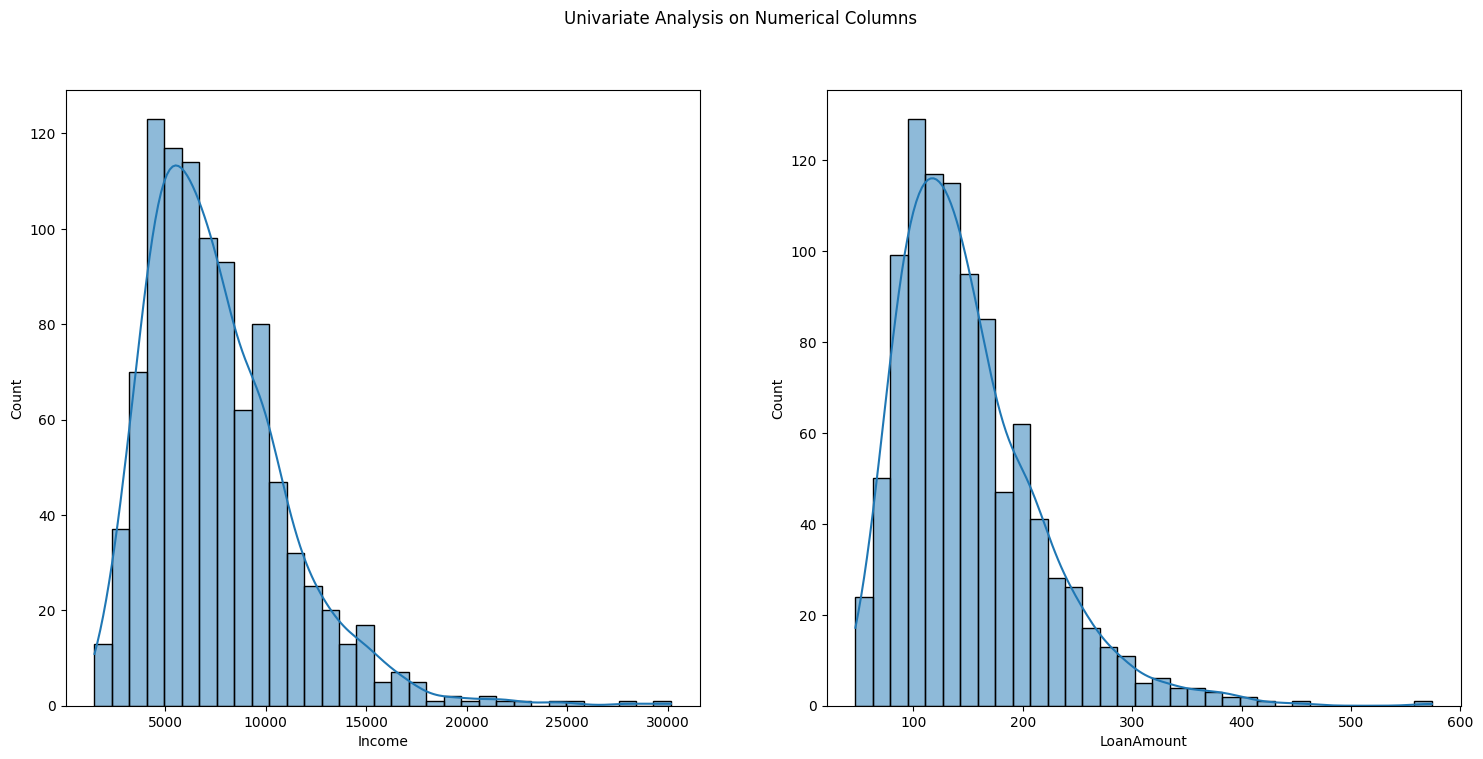

In [1123]:
plt.rcParams['figure.figsize'] = (18,8)

plt.subplot(1,2,1)
sns.histplot(data['Income'], kde= True)

plt.subplot(1,2,2)
sns.histplot(data['LoanAmount'], kde=True)

plt.suptitle('Univariate Analysis on Numerical Columns')
plt.show()

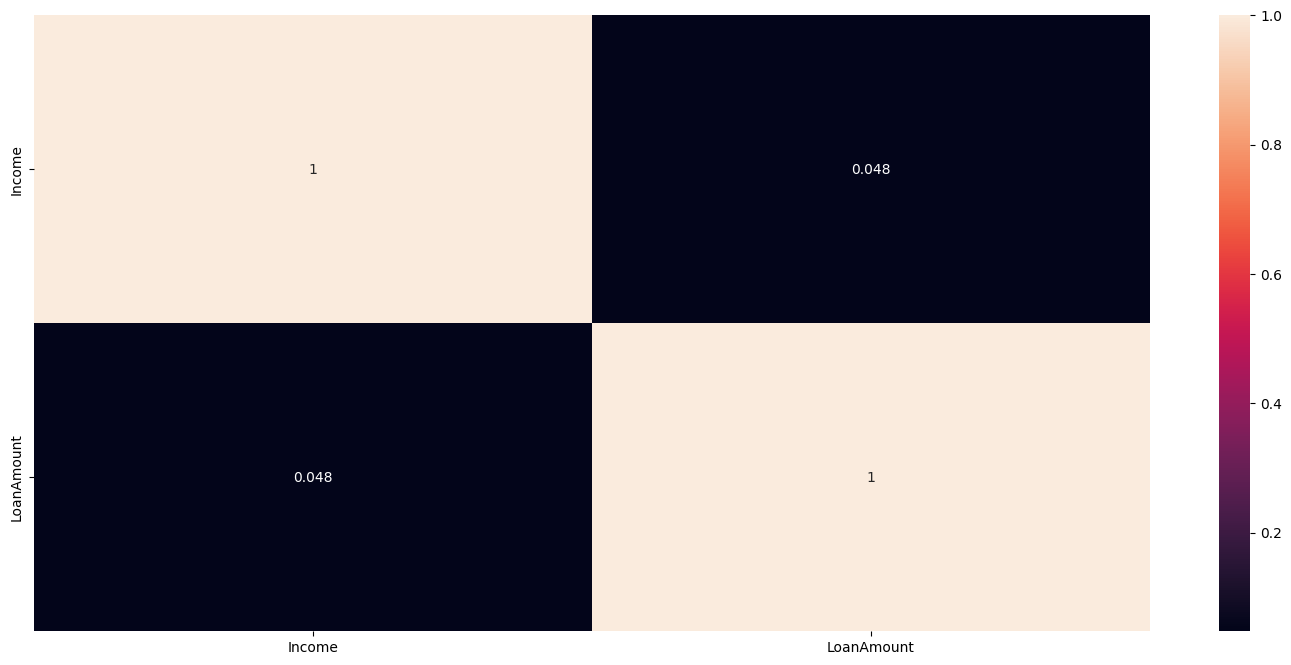

In [1124]:
sns.heatmap(data[continous].corr(), annot=True)
plt.show()

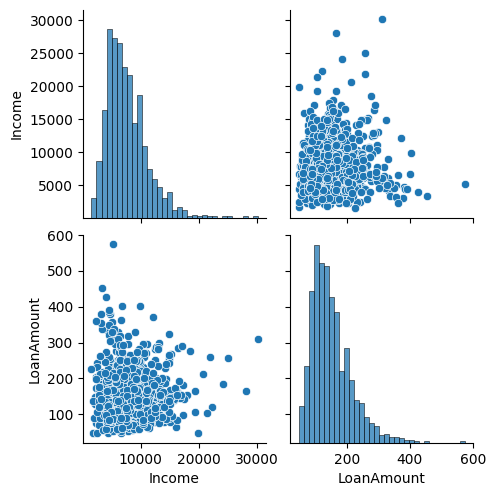

In [1125]:
sns.pairplot(data[continous])
plt.show()

**EDA for Discrete Variables**

In [1126]:
data[discrete_categorical].describe()

,Gender,Married,Education,Self_Employed,Credit_History,Property_Area,Loan_Status
count,988,990,1000,988,985,990,1000
unique,2,2,2,2,2,3,2
top,Male,Yes,Graduate,No,good,Semi Urban,Approved
freq,664,622,735,838,799,373,812


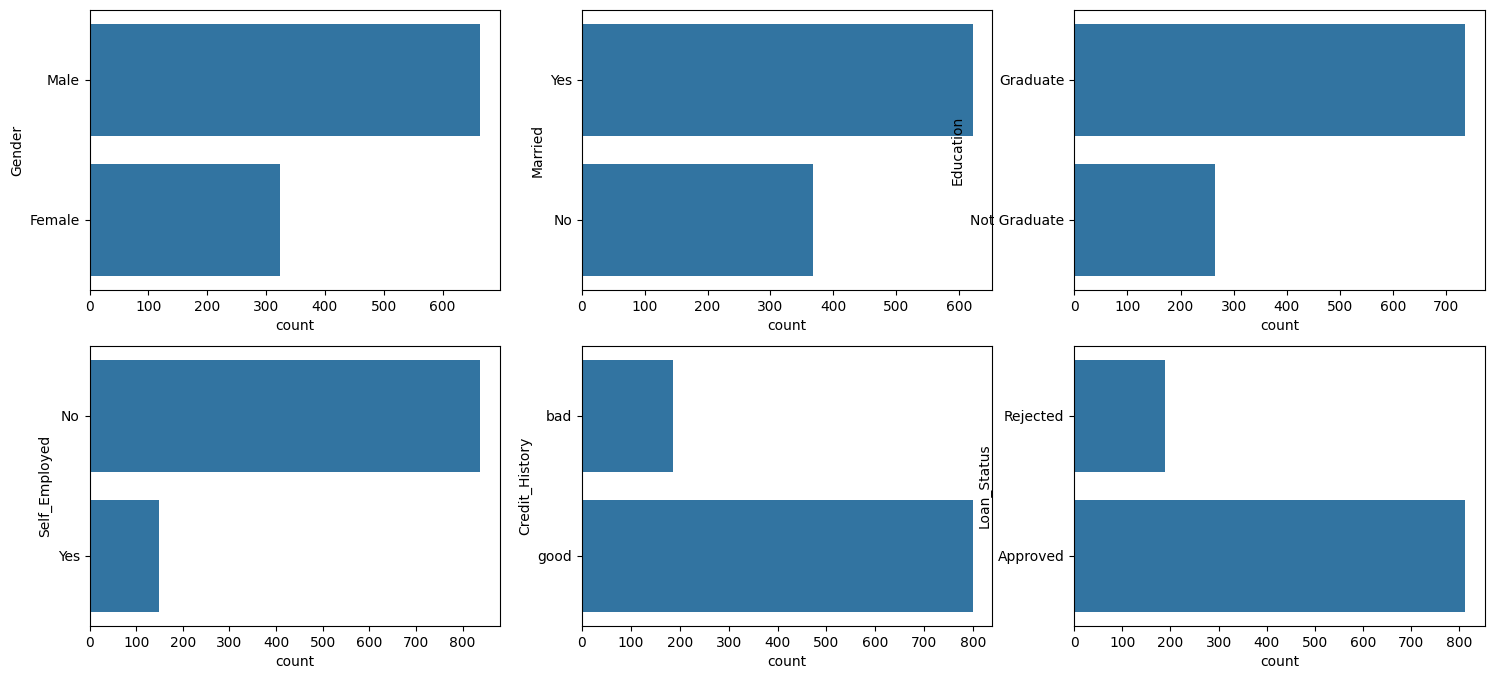

<Figure size 1800x800 with 0 Axes>

In [1127]:
plt.rcParams['figure.figsize'] = (18,8)

plt.subplot(2,3,1)
sns.countplot(data.Gender)

plt.subplot(2,3,2)
sns.countplot(data.Married)

plt.subplot(2,3,3)
sns.countplot(data.Education)

plt.subplot(2,3,4)
sns.countplot(data.Self_Employed)

plt.subplot(2,3,5)
sns.countplot(data.Credit_History)

# plt.subplot(2,3,6)
# sns.countplot(data.Property_Area)

plt.subplot(2,3,6)
sns.countplot(data.Loan_Status)
plt.show()

plt.suptitle('Univariate Analysis on Categorical Columns')
plt.show()

In [1128]:
# Lets compare all the Categories with respect to the Loan Status to understand the overall Impact

print('Impact of Marraige on Loan Status')
print(pd.crosstab(data.Loan_Status, data.Married))
print('/n')

print('Impact of Dependents on Loan Status')
print(pd.crosstab(data.Loan_Status, data.Dependents))
print('/n')

print('Impact of Education on Loan Status')
print(pd.crosstab(data.Loan_Status, data.Education))
print('/n')

print('Impact of Employment on Loan Status')
print(pd.crosstab(data.Loan_Status, data.Self_Employed))
print('/n')


print('Impact of Property on Loan Status')
print(pd.crosstab(data.Loan_Status, data.Property_Area))
print('/n')


print('Impact of Credit Score on Loan Status')
print(pd.crosstab(data.Loan_Status, data.Credit_History))
print('/n')




Impact of Marraige on Loan Status
Married       No  Yes
Loan_Status          
Approved     293  513
Rejected      75  109
/n
Impact of Dependents on Loan Status
Dependents     0    1    2  3+
Loan_Status                   
Approved     470  133  141  54
Rejected     100   27   39  21
/n
Impact of Education on Loan Status
Education    Graduate  Not Graduate
Loan_Status                        
Approved          607           205
Rejected          128            60
/n
Impact of Employment on Loan Status
Self_Employed   No  Yes
Loan_Status            
Approved       686  117
Rejected       152   33
/n
Impact of Property on Loan Status
Property_Area  Rural  Semi Urban  Urban
Loan_Status                            
Approved         244         305    253
Rejected          61          68     59
/n
Impact of Credit Score on Loan Status
Credit_History  bad  good
Loan_Status              
Approved         42   759
Rejected        144    40
/n


**Check for Missing Values**

In [1129]:
data.isnull().sum()

Gender              12
Married             10
Dependents          15
Education            0
Self_Employed       12
LoanAmount          12
Loan_Amount_Term    10
Credit_History      15
Property_Area       10
Loan_Status          0
Income              10
dtype: int64

**Check for Skewness**

In [1130]:
data[continous].skew()

Income        1.469631
LoanAmount    1.390596
dtype: float64

**Check Outliers**

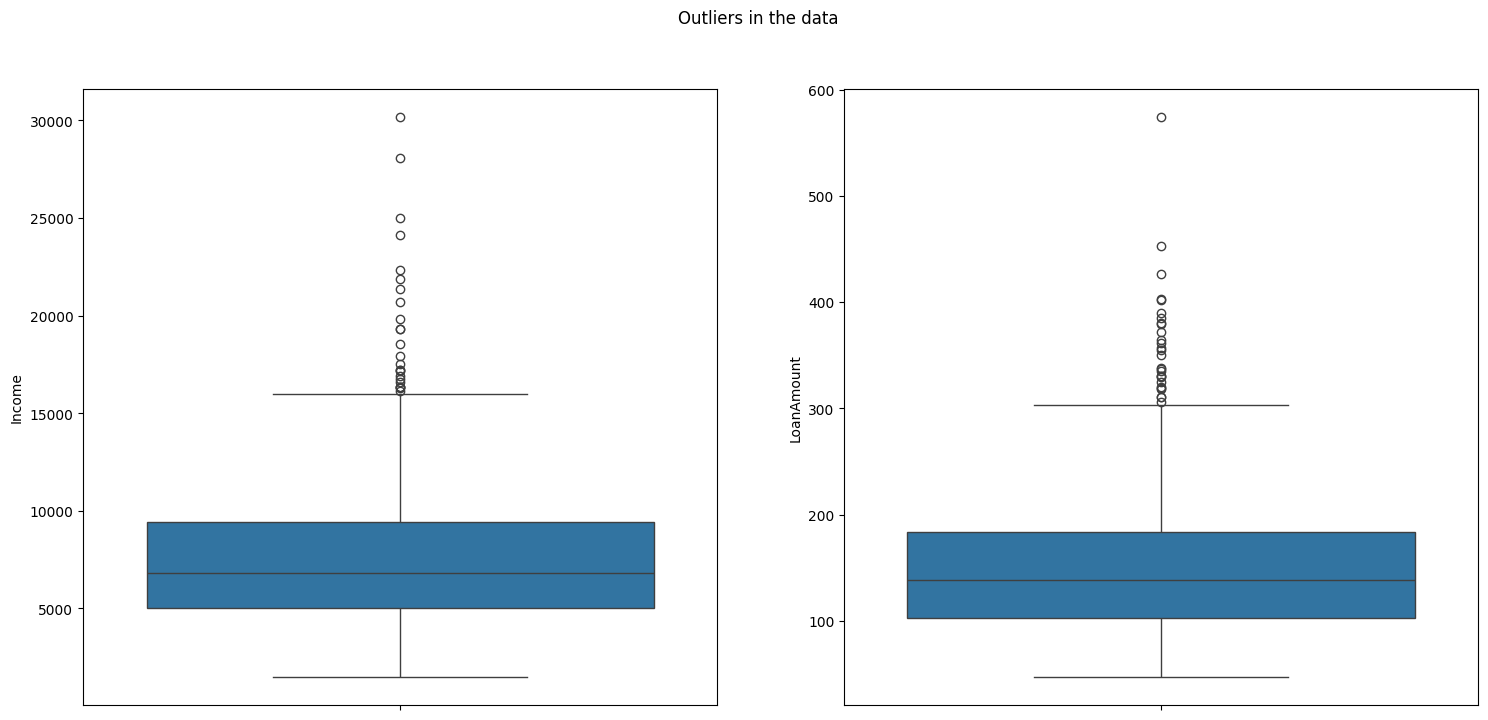

In [1131]:
# lets visualize the outliers using  box plot

plt.subplot(1,2,1)
sns.boxplot(data.Income)

plt.subplot(1,2,2)
sns.boxplot(data.LoanAmount)

plt.suptitle('Outliers in the data')
plt.show()

## **Data Preparation**

1. Data Cleaning
    - Wrong data
    - Wrong data type
    - duplicates
    - Missing values
    - outliers

2. Data Wrangling
    - transformation (applicable only on continous)
    - scaling  (applicable only on continous)
    - encoding (applicable only on discrete categorical)
 - **in the data wrangling  don't apply scaling on "count" variables and dont' apply transformation on "count" variables**

**Wrong Data Treatment**

In [1132]:
data.Dependents = data.Dependents.replace({'3+':3})
data.Dependents = data.Dependents.fillna(0)


In [1133]:
data.Dependents.unique()

array(['0', '2', '1', 3, 0], dtype=object)

**Data type conversion**

In [1134]:
data.Dependents = data.Dependents.astype('int')

In [1135]:
data.Credit_History.unique()
data['Credit_History'] = data.Credit_History.replace({'good':1, 'bad':0})

# data.Credit_History = data.Credit_History.fillna(data.Credit_History.mode[0])
data = data.dropna(subset=['Credit_History'])

data.Credit_History.unique()

array([0, 1], dtype=object)

In [1136]:
data.Credit_History = data.Credit_History.astype('int')


In [1137]:
data.Dependents.unique()
data.Dependents.dtypes

dtype('int64')

**Missing Values Treatments**

In [1138]:
data.isnull().sum()

Gender              12
Married              8
Dependents           0
Education            0
Self_Employed       12
LoanAmount          12
Loan_Amount_Term    10
Credit_History       0
Property_Area       10
Loan_Status          0
Income              10
dtype: int64

In [1139]:
data[data['Gender'].isnull()]

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income
21,NaN,Yes,0,Graduate,No,81.0,180.0,1,Rural,Approved,9523.0
54,NaN,No,2,Graduate,No,222.0,360.0,0,Semi Urban,Rejected,4152.0
60,NaN,No,0,Graduate,No,96.0,360.0,1,Rural,Approved,5440.0
104,NaN,No,2,Graduate,No,140.0,360.0,1,Semi Urban,Approved,7668.0
284,NaN,Yes,0,Graduate,No,79.0,480.0,1,Rural,Rejected,15062.0
444,NaN,No,0,Not Graduate,No,139.0,360.0,0,Rural,Rejected,7560.0
483,NaN,Yes,0,Not Graduate,No,172.0,360.0,1,Urban,Approved,5135.0
498,NaN,Yes,3,Graduate,No,65.0,360.0,0,Semi Urban,Rejected,3326.0
552,NaN,No,2,Graduate,No,93.0,360.0,1,Semi Urban,Approved,10081.0
725,NaN,Yes,0,Not Graduate,Yes,128.0,360.0,1,Rural,Approved,15063.0


In [1140]:
data[data.Married.isnull()]

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income
92,Female,NaN,0,Graduate,No,79.0,360.0,0,Semi Urban,Rejected,5770.0
206,Male,NaN,0,Not Graduate,No,78.0,360.0,1,Rural,Approved,6393.0
557,Male,NaN,0,Graduate,No,121.0,300.0,0,Urban,Approved,7571.0
587,Male,NaN,1,Not Graduate,Yes,102.0,360.0,1,Semi Urban,Approved,5074.0
628,Male,NaN,0,Not Graduate,No,133.0,360.0,0,Urban,Rejected,5099.0
632,Male,NaN,0,Graduate,No,149.0,480.0,1,Rural,Approved,4030.0
770,Male,NaN,0,Graduate,Yes,248.0,480.0,1,Semi Urban,Rejected,9115.0
939,Male,NaN,0,Graduate,No,138.0,360.0,1,Urban,Approved,14907.0


In [1141]:
data[data.Self_Employed.isnull()]

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income
31,Male,Yes,0,Graduate,NaN,59.0,360.0,1,Rural,Approved,5558.0
98,Male,No,2,Graduate,NaN,205.0,360.0,1,Urban,Approved,7777.0
217,Female,No,0,Graduate,NaN,75.0,360.0,0,Urban,Rejected,5880.0
236,Male,No,2,Graduate,NaN,265.0,360.0,1,Urban,Approved,14922.0
279,Female,Yes,0,Not Graduate,NaN,138.0,360.0,0,Semi Urban,Approved,9472.0
321,Female,Yes,1,Graduate,NaN,158.0,360.0,1,Urban,Approved,NaN
341,Male,Yes,0,Graduate,NaN,210.0,240.0,1,Urban,Approved,10891.0
458,Male,Yes,0,Graduate,NaN,160.0,360.0,0,Semi Urban,Rejected,7152.0
507,Female,Yes,0,Graduate,NaN,160.0,360.0,1,Semi Urban,Approved,11911.0
733,Male,Yes,3,Graduate,NaN,191.0,180.0,0,Rural,Rejected,4468.0


In [1142]:
data[data.Credit_History.isnull()]

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income


In [1143]:
data.Married = data.Married.fillna(data.Married.mode()[0])
data.Gender = data.Gender.fillna(data.Gender.mode()[0])
data.Self_Employed = data.Self_Employed.fillna(data.Self_Employed.mode()[0])
data.Property_Area = data.Property_Area.fillna(data.Property_Area.mode()[0])

data = data.dropna(subset=['Income', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History'])




In [1144]:
data.isnull().sum()

Gender              0
Married             0
Dependents          0
Education           0
Self_Employed       0
LoanAmount          0
Loan_Amount_Term    0
Credit_History      0
Property_Area       0
Loan_Status         0
Income              0
dtype: int64

In [1145]:
data.info()

<class 'pandas.DataFrame'>
Index: 953 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            953 non-null    str    
 1   Married           953 non-null    str    
 2   Dependents        953 non-null    int64  
 3   Education         953 non-null    str    
 4   Self_Employed     953 non-null    str    
 5   LoanAmount        953 non-null    float64
 6   Loan_Amount_Term  953 non-null    float64
 7   Credit_History    953 non-null    int64  
 8   Property_Area     953 non-null    str    
 9   Loan_Status       953 non-null    str    
 10  Income            953 non-null    float64
dtypes: float64(3), int64(2), str(6)
memory usage: 121.1 KB


**data type concersion**

In [1146]:
data.Dependents = data.Dependents.astype('int')
data.Loan_Amount_Term = data.Loan_Amount_Term.astype('int')

In [1147]:
data.duplicated().sum()

np.int64(0)

In [1148]:
data.info()

<class 'pandas.DataFrame'>
Index: 953 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Gender            953 non-null    str    
 1   Married           953 non-null    str    
 2   Dependents        953 non-null    int64  
 3   Education         953 non-null    str    
 4   Self_Employed     953 non-null    str    
 5   LoanAmount        953 non-null    float64
 6   Loan_Amount_Term  953 non-null    int64  
 7   Credit_History    953 non-null    int64  
 8   Property_Area     953 non-null    str    
 9   Loan_Status       953 non-null    str    
 10  Income            953 non-null    float64
dtypes: float64(2), int64(3), str(6)
memory usage: 121.1 KB


**Outliers Treatments**

In [1149]:
# outliers should be retrained (because really sone people will have high income)

**Encoding**

In [1150]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income
0,Male,Yes,0,Graduate,No,140.0,360,0,Rural,Rejected,5197.0
1,Female,Yes,0,Not Graduate,No,75.0,360,1,Semi Urban,Approved,2212.0
2,Female,No,2,Graduate,No,171.0,360,1,Semi Urban,Approved,9551.0
3,Male,No,0,Graduate,No,195.0,360,1,Rural,Approved,11536.0
4,Male,No,0,Graduate,Yes,110.0,360,1,Urban,Approved,7581.0


In [1151]:
data.Gender = data.Gender.replace({'Male':1,'Female':0})
data.Married = data.Married.replace({'Yes':1, 'No':0})
data.Education = data.Education.replace({'Graduate':1, 'Not Graduate':0})
data.Self_Employed = data.Self_Employed.replace({'Yes':1, 'No':0})
data.Property_Area = data.Property_Area.replace({'Rural':0, 'Semi Urban': 1, 'Urban':2})
data.Loan_Status = data.Loan_Status.replace({'Approved':'Yes','Rejected':'No'})


In [1152]:
data.Loan_Status = data.Loan_Status.replace({'Yes':1,'No':0})
data.Loan_Status.unique()
data.Loan_Status = data.Loan_Status.astype('int')
data.Loan_Status.dtypes



dtype('int64')

In [1153]:
data.head()

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income
0,1,1,0,1,0,140.0,360,0,0,0,5197.0
1,0,1,0,0,0,75.0,360,1,1,1,2212.0
2,0,0,2,1,0,171.0,360,1,1,1,9551.0
3,1,0,0,1,0,195.0,360,1,0,1,11536.0
4,1,0,0,1,1,110.0,360,1,2,1,7581.0


**Transformations**

In [1154]:
from scipy.stats import boxcox
data.Income, a = boxcox(data.Income)
data.LoanAmount, c = boxcox(data.LoanAmount)

In [1155]:
data.Income.skew()

np.float64(-3.874758451075835e-05)

In [1156]:
data.LoanAmount.skew()

np.float64(0.0017625132746494434)

In [1157]:
data

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income
0,1,1,0,1,0,3.967917,360,0,0,0,10.430075
1,0,1,0,0,0,3.560792,360,1,1,1,9.199867
2,0,0,2,1,0,4.093501,360,1,1,1,11.335750
3,1,0,0,1,0,4.174708,360,1,0,1,11.621829
4,1,0,0,1,1,3.813386,360,1,2,1,10.989056
...,...,...,...,...,...,...,...,...,...,...,...
994,1,0,0,1,1,4.325669,480,1,2,1,11.207982
996,0,0,0,1,1,3.858727,240,1,0,1,11.731770
997,1,1,0,1,0,3.628508,360,1,0,1,11.451604
998,0,1,0,1,0,3.858727,360,1,2,1,10.965641


In [1158]:
data.Loan_Amount_Term = data.Loan_Amount_Term / 12

In [1159]:
data

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Income
0,1,1,0,1,0,3.967917,30.0,0,0,0,10.430075
1,0,1,0,0,0,3.560792,30.0,1,1,1,9.199867
2,0,0,2,1,0,4.093501,30.0,1,1,1,11.335750
3,1,0,0,1,0,4.174708,30.0,1,0,1,11.621829
4,1,0,0,1,1,3.813386,30.0,1,2,1,10.989056
...,...,...,...,...,...,...,...,...,...,...,...
994,1,0,0,1,1,4.325669,40.0,1,2,1,11.207982
996,0,0,0,1,1,3.858727,20.0,1,0,1,11.731770
997,1,1,0,1,0,3.628508,30.0,1,0,1,11.451604
998,0,1,0,1,0,3.858727,30.0,1,2,1,10.965641


#### **X & y**

In [1160]:
X = data.drop('Loan_Status' ,axis=1)
y = data['Loan_Status']

In [1161]:
X

,Gender,Married,Dependents,Education,Self_Employed,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Income
0,1,1,0,1,0,3.967917,30.0,0,0,10.430075
1,0,1,0,0,0,3.560792,30.0,1,1,9.199867
2,0,0,2,1,0,4.093501,30.0,1,1,11.335750
3,1,0,0,1,0,4.174708,30.0,1,0,11.621829
4,1,0,0,1,1,3.813386,30.0,1,2,10.989056
...,...,...,...,...,...,...,...,...,...,...
994,1,0,0,1,1,4.325669,40.0,1,2,11.207982
996,0,0,0,1,1,3.858727,20.0,1,0,11.731770
997,1,1,0,1,0,3.628508,30.0,1,0,11.451604
998,0,1,0,1,0,3.858727,30.0,1,2,10.965641


In [1162]:
y

0      0
1      1
2      1
3      1
4      1
      ..
994    1
996    1
997    1
998    1
999    0
Name: Loan_Status, Length: 953, dtype: int64

**train_test_split**

In [1163]:
Train = []
Test = []
CV =[]

for i in range(1,101):
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=i)

    from sklearn.linear_model import LogisticRegression
    log_default  = LogisticRegression()
    log_default.fit(X_train, y_train)
    # log_default.f(X_train, y_train)

    y_pred_train = log_default.predict(X_train)
    y_Pred_test = log_default.predict(X_test)

    from sklearn.metrics import accuracy_score
    Train.append(accuracy_score(y_train, y_pred_train))
    Test.append(accuracy_score(y_test,y_Pred_test))

    from sklearn.model_selection import cross_val_score
    CV.append(cross_val_score(log_default, X_train, y_train, cv = 5, scoring='accuracy').mean())

em = pd.DataFrame({'Train':Train,'Test':Test,'CV':CV})

gm = em[(abs(em['Train']-em['Test'])<=0.05)& (abs(em['Test']-em['CV'])<=0.05)]

rs = gm[gm['CV']==gm['CV'].max()].index.to_list()[0]
print('Best random_state number : ',rs)


Best random_state number :  56


In [1165]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=56)




## **Modelling & Evaluation**

In [1166]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import  accuracy_score
from sklearn.model_selection import cross_val_score
